In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/drive/MyDrive/spaceship-titanic - Copy/archive (25)/jee_marks_percentile_rank_2009_2026.csv')
df.head()

,Year,Marks,Percentile,Rank,Total_Candidates
0,2009,296,100.000000,1,800000
1,2009,295,100.000000,1,800000
2,2009,297,100.000000,1,800000
3,2009,284,99.619975,3040,800000
4,2009,284,100.000000,1,800000


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              1620 non-null   int64  
 1   Marks             1620 non-null   int64  
 2   Percentile        1620 non-null   float64
 3   Rank              1620 non-null   int64  
 4   Total_Candidates  1620 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 63.4 KB


,Year,Marks,Percentile,Rank,Total_Candidates
count,1620.000000,1620.000000,1620.000000,1.620000e+03,1.620000e+03
mean,2017.500000,149.035802,68.040127,3.684445e+05,1.148889e+06
std,5.189729,86.677054,34.111475,4.008154e+05,1.814055e+05
min,2009.000000,2.000000,0.317587,1.000000e+00,8.000000e+05
25%,2013.000000,74.000000,28.979665,4.491550e+04,1.000000e+06
50%,2017.500000,149.000000,84.749529,1.646180e+05,1.190000e+06
75%,2022.000000,224.000000,96.312400,6.721380e+05,1.300000e+06
max,2026.000000,297.000000,100.000000,1.379224e+06,1.400000e+06


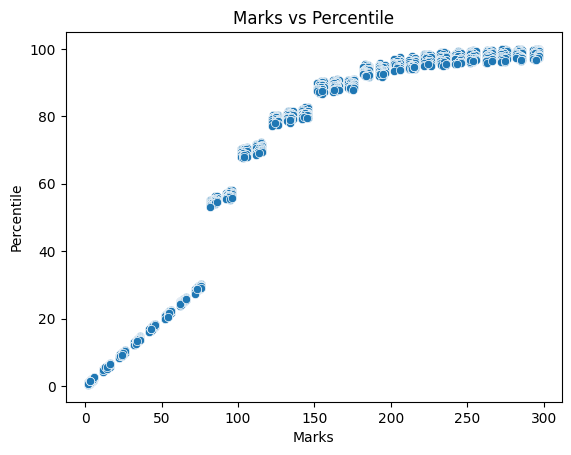

In [4]:
sns.scatterplot(x="Marks",y="Percentile",data=df)
plt.title("Marks vs Percentile")
plt.show()


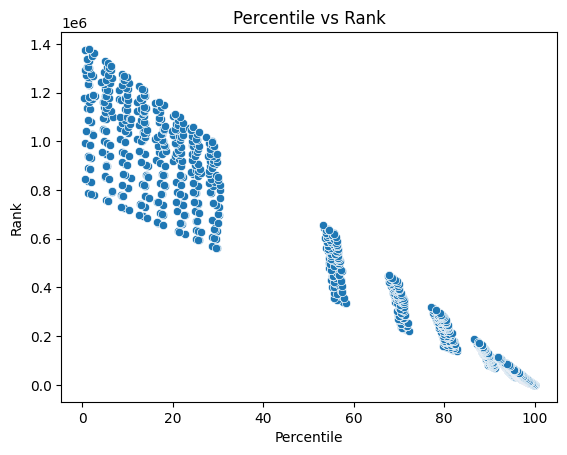

In [5]:
sns.scatterplot(x="Percentile",y="Rank",data=df)
plt.title("Percentile vs Rank")
plt.show()


In [6]:
X = df[["Marks","Percentile","Year","Total_Candidates"]]
y = df["Rank"]

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=200,random_state=42)
model.fit(X_train,y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [9]:
y_pred = model.predict(X_test)


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 4292.6089660493835
MSE: 97736720.91116737
R2 Score: 0.999395988812386


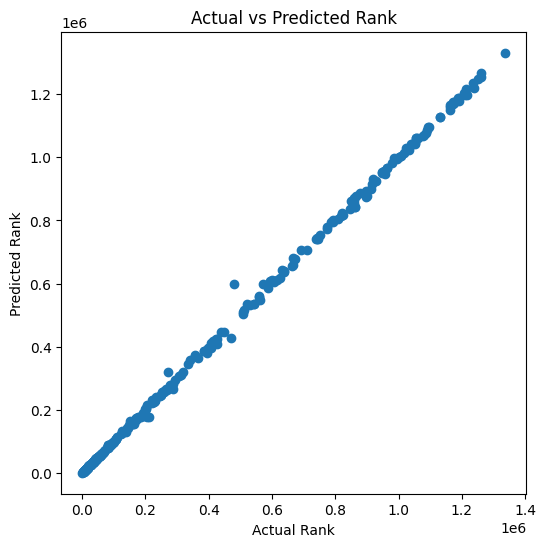

In [11]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Rank")
plt.ylabel("Predicted Rank")
plt.title("Actual vs Predicted Rank")

plt.show()

In [12]:
college_df = pd.read_csv("/content/drive/MyDrive/spaceship-titanic - Copy/archive (25)/jee_college_cutoffs_nits.csv")

In [13]:
college_df.columns

Index(['Year', 'Institute', 'Branch', 'Category', 'Opening_Rank',
       'Closing_Rank', 'Quota'],
      dtype='object')

In [14]:
college_df.head()

,Year,Institute,Branch,Category,Opening_Rank,Closing_Rank,Quota
0,2020,NIT Trichy,Computer Science and Engineering,General,2830,4601,Other State
1,2020,NIT Trichy,Computer Science and Engineering,OBC-NCL,1055,1833,Other State
2,2020,NIT Trichy,Computer Science and Engineering,SC,734,1814,Other State
3,2020,NIT Trichy,Computer Science and Engineering,ST,577,1330,Other State
4,2020,NIT Trichy,Computer Science and Engineering,EWS,977,2157,Other State


In [15]:
def recommend_colleges(rank, category, quota):

    possible = college_df[
        (college_df["Opening_Rank"] <= rank) &
        (college_df["Closing_Rank"] >= rank) &
        (college_df["Category"] == category) &
        (college_df["Quota"] == quota)
    ]

    return possible[["Institute","Branch","Closing_Rank"]].head(10).reset_index(drop=True)

In [16]:
sample = pd.DataFrame(
    [[210, 99.3, 2024, 1200000]],
    columns=["Marks","Percentile","Year","Total_Candidates"]
)

pred_rank = model.predict(sample)

rank = int(pred_rank[0])

print("Predicted Rank:", rank)

recommend_colleges(rank, "General", "Other State")

Predicted Rank: 7172


,Institute,Branch,Closing_Rank
0,NIT Trichy,Electronics and Communication Engineering,7402
1,NIT Surathkal,Electronics and Communication Engineering,7389
2,NIT Warangal,Electronics and Communication Engineering,7206
3,NIT Surathkal,Mechanical Engineering,8787
4,NIT Warangal,Civil Engineering,8104
5,NIT Calicut,Information Technology,8104
6,NIT Durgapur,Computer Science and Engineering,8981
7,NIT Durgapur,Information Technology,7763
8,NIT Jaipur,Information Technology,8495
9,NIT Trichy,Electrical Engineering,8112


In [17]:
import pickle

pickle.dump(model, open("rank_model.pkl","wb"))

In [21]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 112.1 MB/s eta 0:00:00


In [22]:
!streamlit --version

Streamlit, version 1.55.0


In [32]:
app_code = """
import streamlit as st
import pandas as pd
import pickle

# Load model
model = pickle.load(open("rank_model.pkl","rb"))

# Load dataset
college_df = pd.read_csv("jee_college_cutoffs_nits.csv")

st.title("JEE Rank & NIT College Predictor")

marks = st.number_input("Marks")
percentile = st.number_input("Percentile")

category = st.selectbox(
    "Category",
    ["General","OBC-NCL","SC","ST","EWS"]
)

quota = st.selectbox(
    "Quota",
    ["Other State","Home State"]
)

year = st.number_input("Year", value=2024)
candidates = st.number_input("Total Candidates", value=1200000)

if st.button("Predict Rank"):

    sample = [[marks, percentile, year, candidates]]

    rank = model.predict(sample)
    rank = int(rank[0])

    st.write("### Predicted Rank:", rank)

    possible = college_df[
        (college_df["Opening_Rank"] <= rank) &
        (college_df["Closing_Rank"] >= rank) &
        (college_df["Category"] == category) &
        (college_df["Quota"] == quota)
    ]

    st.write("### Recommended Colleges")

    st.dataframe(
        possible[["Institute","Branch","Closing_Rank"]]
        .head(10)
        .reset_index(drop=True)
    )
"""

# Save the streamlit file
with open("streamlit_jee_app.py","w") as f:
    f.write(app_code)

print("Streamlit app created successfully!")

Streamlit app created successfully!
